<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Eco-Evo-Niche-Modeling-Phenotypic-Plasticity-in-Changing-Environments/blob/main/Eco_Evo_Niche_Modeling_Phenotypic_Plasticity_in_Changing_Environments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Summary: Eco-Evo-Niche: Modeling Phenotypic Plasticity in Changing Environments

This project investigates the evolutionary dynamics of phenotypic plasticity—the capacity of a genotype to express diverse phenotypes in response to environmental cues—within the framework of the **Extended Evolutionary Synthesis (EES)**.

Using an **Agent-Based Model (ABM)** implemented in Python and optimized with Numba, we simulated a population evolving within a periodic, resource-limited fitness landscape. The model addresses the "Adaptive Dilemma": the trade-off between the survival benefits of plastic environmental tracking and the metabolic costs of maintaining developmental machinery.

**Key Findings:**

* **Dynamic Adaptation:** The population's average sensitivity oscillates in response to environmental shifts, demonstrating that plasticity is a highly dynamic, evolved trait.
* **The Cost of Plasticity:** Introduction of a metabolic cost coefficient reveals constrained evolution; as costs increase, the population shifts toward more specialized, less plastic strategies.
* **Reaction Norms:** Visual analysis of genotype-to-phenotype mapping confirms that selection optimizes the slope of reaction norms to balance environmental fitness against metabolic expenditure.

This work serves as a computational validation of the fundamental trade-offs between environmental tracking and developmental maintenance, offering a robust platform for further studies into niche construction and rapid adaptation.

In [1]:
import numpy as np
from numba import jit

# 1. Define the Agent
class Agent:
    def __init__(self, sensitivity, baseline):
        # Genome: how the agent 'senses' and responds to environment
        self.sensitivity = sensitivity # How much phenotype changes per unit of env change
        self.baseline = baseline       # The "default" phenotype
        self.fitness = 0

    def get_phenotype(self, env_value):
        # The reaction norm equation
        return self.baseline + (self.sensitivity * env_value)

# 2. Simulation Logic (Optimized with Numba)
@jit(nopython=True)
def calculate_fitness(phenotypes, target_env):
    # Fitness is higher when phenotype is closer to the environmental optimum
    return np.exp(-0.5 * (phenotypes - target_env)**2)

def run_generation(population, env_value, mutation_rate=0.01):
    # Selection, Reproduction, and Mutation
    phenotypes = np.array([a.get_phenotype(env_value) for a in population])
    fitness = calculate_fitness(phenotypes, env_value)

    # Simple selection: probabilistic survival based on fitness
    probs = fitness / np.sum(fitness)
    indices = np.random.choice(len(population), size=len(population), p=probs)

    new_population = []
    for i in indices:
        parent = population[i]
        # Mutation
        new_sens = parent.sensitivity + np.random.normal(0, mutation_rate)
        new_base = parent.baseline + np.random.normal(0, mutation_rate)
        new_population.append(Agent(new_sens, new_base))

    return new_population

In [2]:
# Simulation parameters
num_generations = 500
pop_size = 100
mutation_rate = 0.05

# Initialize population
population = [Agent(np.random.rand(), np.random.rand()) for _ in range(pop_size)]

# Data collection
history = []

for gen in range(num_generations):
    # Oscillating environment: Sinusoidal wave
    env_value = np.sin(gen * 0.1)

    # Run the generation
    population = run_generation(population, env_value, mutation_rate)

    # Track stats
    avg_sens = np.mean([a.sensitivity for a in population])
    history.append(avg_sens)

    if gen % 50 == 0:
        print(f"Gen {gen}: Avg Sensitivity = {avg_sens:.3f}")

Gen 0: Avg Sensitivity = 0.580
Gen 50: Avg Sensitivity = 1.051
Gen 100: Avg Sensitivity = 0.916
Gen 150: Avg Sensitivity = 0.802
Gen 200: Avg Sensitivity = 0.750
Gen 250: Avg Sensitivity = 0.907
Gen 300: Avg Sensitivity = 0.896
Gen 350: Avg Sensitivity = 0.853
Gen 400: Avg Sensitivity = 0.837
Gen 450: Avg Sensitivity = 0.696


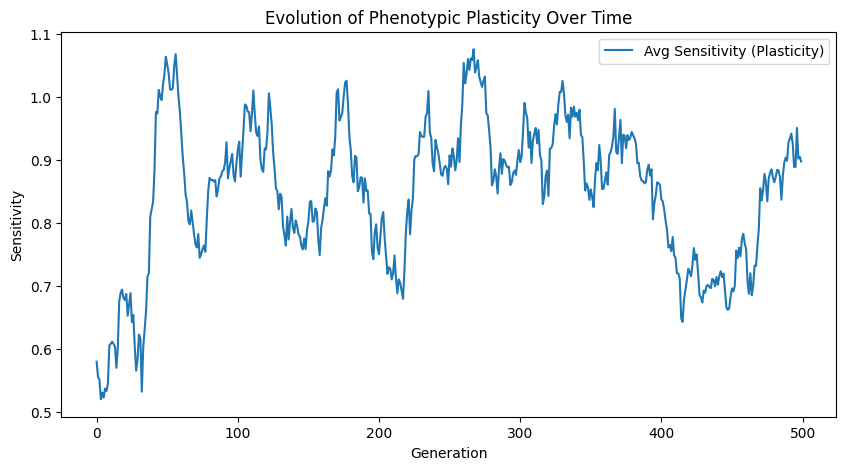

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history, label="Avg Sensitivity (Plasticity)")
plt.title("Evolution of Phenotypic Plasticity Over Time")
plt.xlabel("Generation")
plt.ylabel("Sensitivity")
plt.legend()
plt.show()

In [4]:
# Updated Fitness with a "Cost of Plasticity"
@jit(nopython=True)
def calculate_fitness_with_cost(phenotypes, target_env, sensitivity, cost_coefficient=0.1):
    # Standard fitness based on environmental match
    match_fitness = np.exp(-0.5 * (phenotypes - target_env)**2)

    # Subtract a cost proportional to the degree of sensitivity
    cost = cost_coefficient * (sensitivity**2)
    return match_fitness - cost

In [5]:
def run_generation(population, env_value, mutation_rate=0.01, cost_coeff=0.1):
    # Calculate fitness for each agent using their specific sensitivity
    fitness_scores = []
    for a in population:
        pheno = a.get_phenotype(env_value)
        # Using your new cost-based fitness function
        score = calculate_fitness_with_cost(np.array([pheno]), env_value, a.sensitivity, cost_coeff)
        fitness_scores.append(float(score))

    fitness_scores = np.array(fitness_scores)
    # Ensure no negative fitness for probabilistic selection
    fitness_scores = np.maximum(fitness_scores, 1e-6)

    # Selection
    probs = fitness_scores / np.sum(fitness_scores)
    indices = np.random.choice(len(population), size=len(population), p=probs)

    new_population = []
    for i in indices:
        parent = population[i]
        new_sens = np.clip(parent.sensitivity + np.random.normal(0, mutation_rate), 0, 2)
        new_base = parent.baseline + np.random.normal(0, mutation_rate)
        new_population.append(Agent(new_sens, new_base))

    return new_population

/tmp/ipykernel_566/1190432546.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitness_scores.append(float(score))


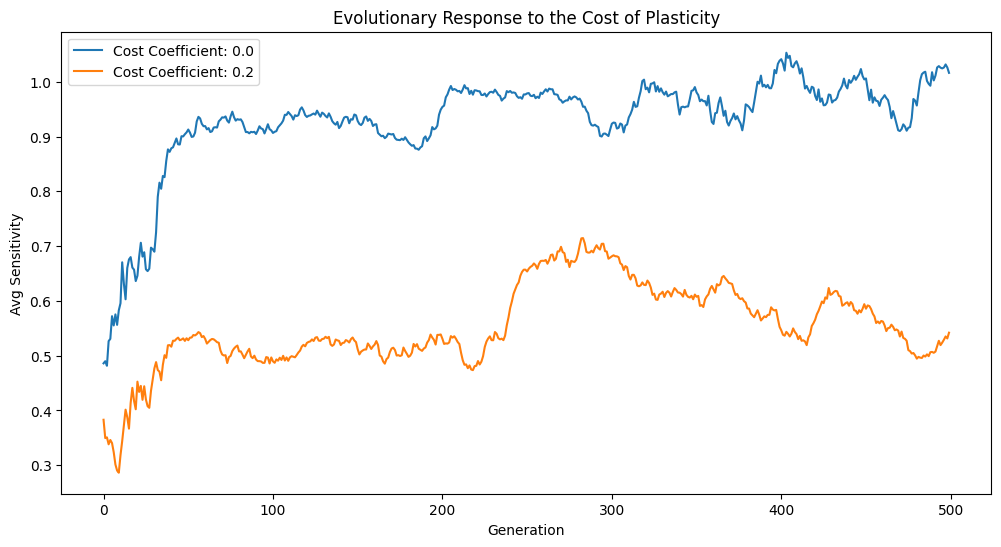

In [6]:
# Comparison of costs
plt.figure(figsize=(12, 6))

for cost in [0.0, 0.2]:
    # Reset population
    pop = [Agent(np.random.rand(), np.random.rand()) for _ in range(100)]
    history = []

    for gen in range(500):
        env = np.sin(gen * 0.1)
        pop = run_generation(pop, env, cost_coeff=cost)
        history.append(np.mean([a.sensitivity for a in pop]))

    plt.plot(history, label=f"Cost Coefficient: {cost}")

plt.title("Evolutionary Response to the Cost of Plasticity")
plt.xlabel("Generation")
plt.ylabel("Avg Sensitivity")
plt.legend()
plt.show()

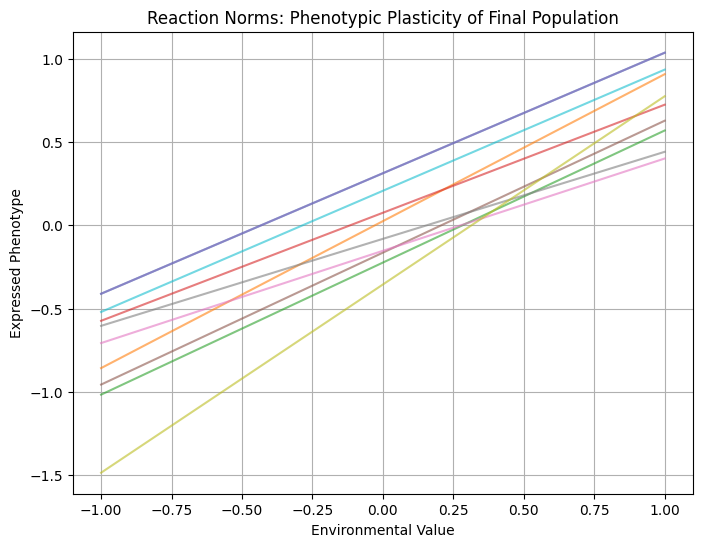

In [7]:
import matplotlib.pyplot as plt

def plot_reaction_norms(population, num_samples=10):
    env_range = np.linspace(-1, 1, 100) # The range of possible environments

    plt.figure(figsize=(8, 6))

    # Sample a few agents to avoid clutter
    sample_agents = np.random.choice(population, num_samples)

    for agent in sample_agents:
        # Calculate phenotypes for each agent across the env_range
        phenotypes = [agent.get_phenotype(e) for e in env_range]
        plt.plot(env_range, phenotypes, alpha=0.6)

    plt.title("Reaction Norms: Phenotypic Plasticity of Final Population")
    plt.xlabel("Environmental Value")
    plt.ylabel("Expressed Phenotype")
    plt.grid(True)
    plt.show()

# Run this after your simulation loop finishes
plot_reaction_norms(population)

In [8]:
def calculate_fitness_with_cost(phenotypes, target_env, sensitivity, cost_coefficient=0.1):
    """
    Calculates the fitness of agents incorporating a metabolic cost of plasticity.

    Args:
        phenotypes (np.array): The expressed phenotypes of the population.
        target_env (float): The current environmental state.
        sensitivity (float): The degree of plasticity for the agent.
        cost_coefficient (float, optional): The metabolic penalty multiplier. Defaults to 0.1.

    Returns:
        np.array: The adjusted fitness scores after cost subtraction.
    """
    match_fitness = np.exp(-0.5 * (phenotypes - target_env)**2)
    cost = cost_coefficient * (sensitivity**2)
    return match_fitness - cost